# Assignment 8 — EDA & Hypothesis Testing  


## Intro

In this assignment, I worked with the UCI Adult Census dataset to explore how factors like education, gender, and weekly working hours relate to income levels. My main hypothesis was that people with higher education are more likely to earn over 50K. I ran some EDA to spot patterns, then used chi-square tests and t-tests to statistically test my assumptions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

# Load data
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
    'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
    'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=column_names,
    sep=', ',
    engine='python'
)

df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [43]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


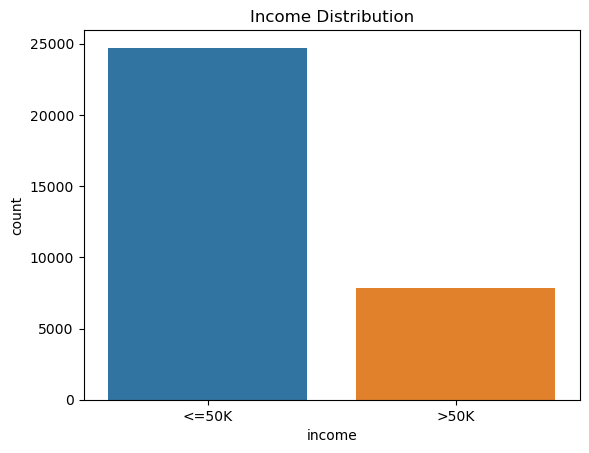

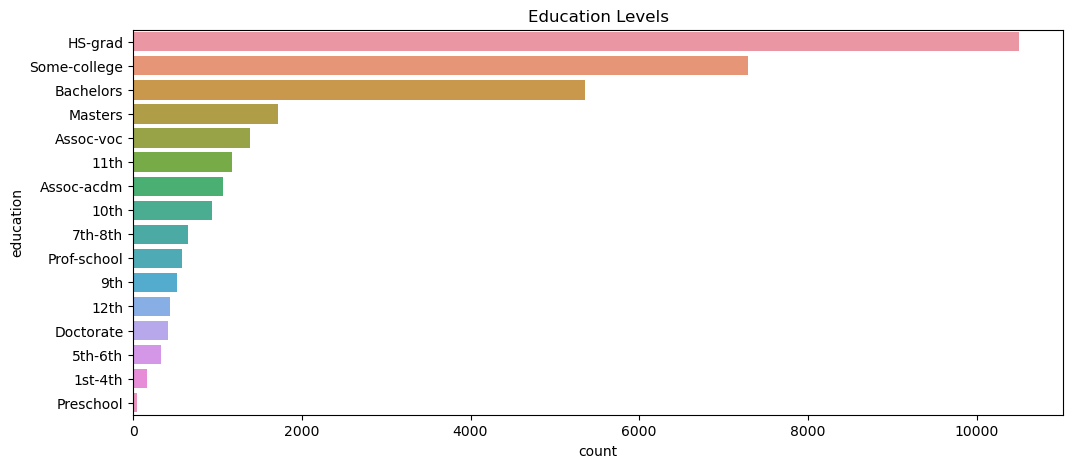

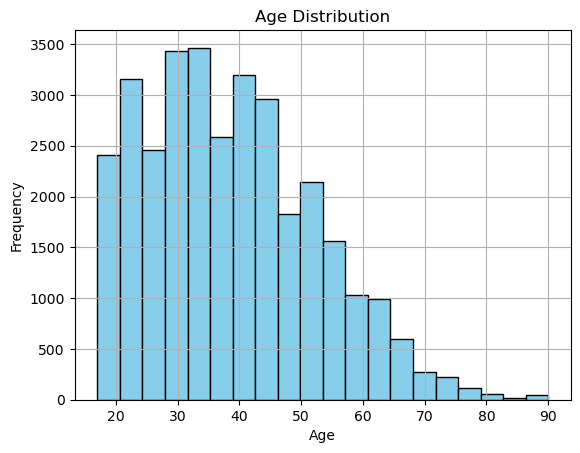

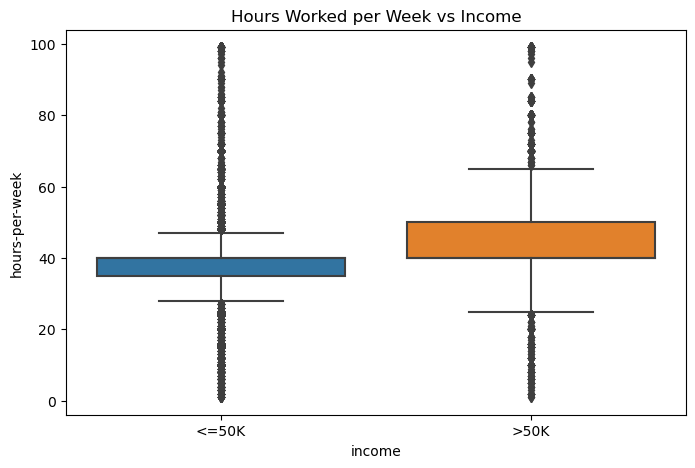

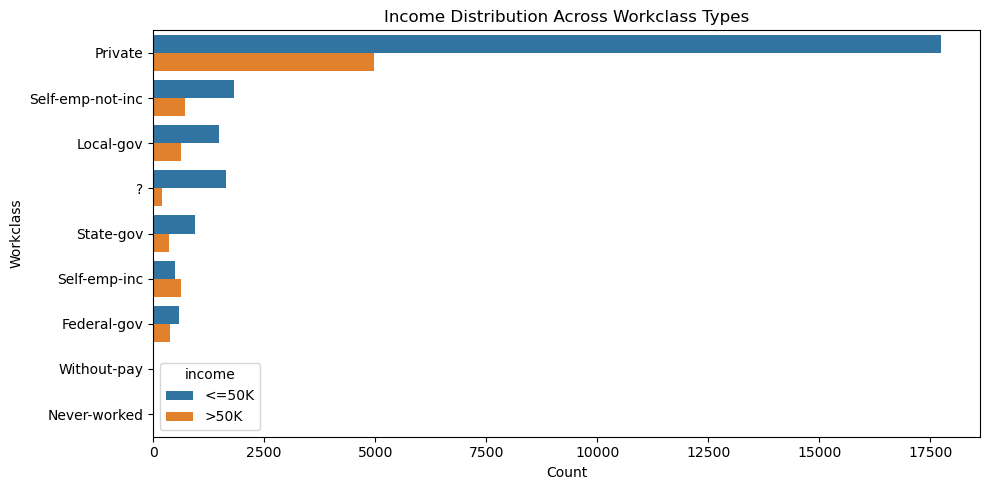

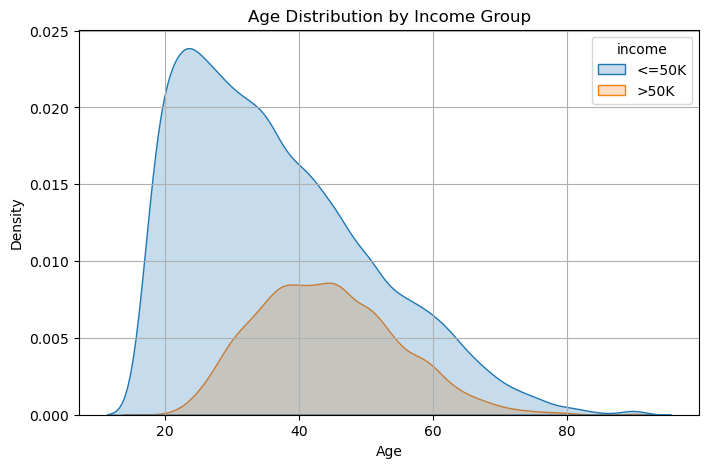

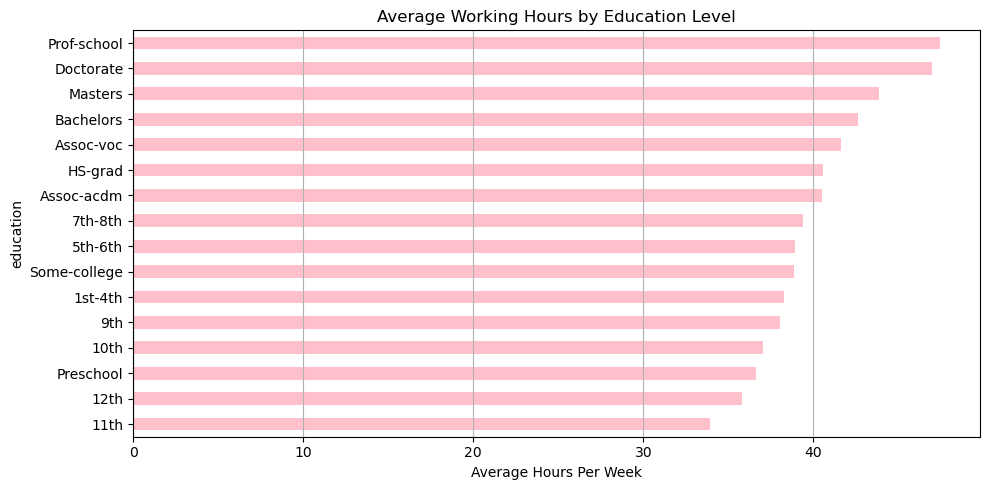

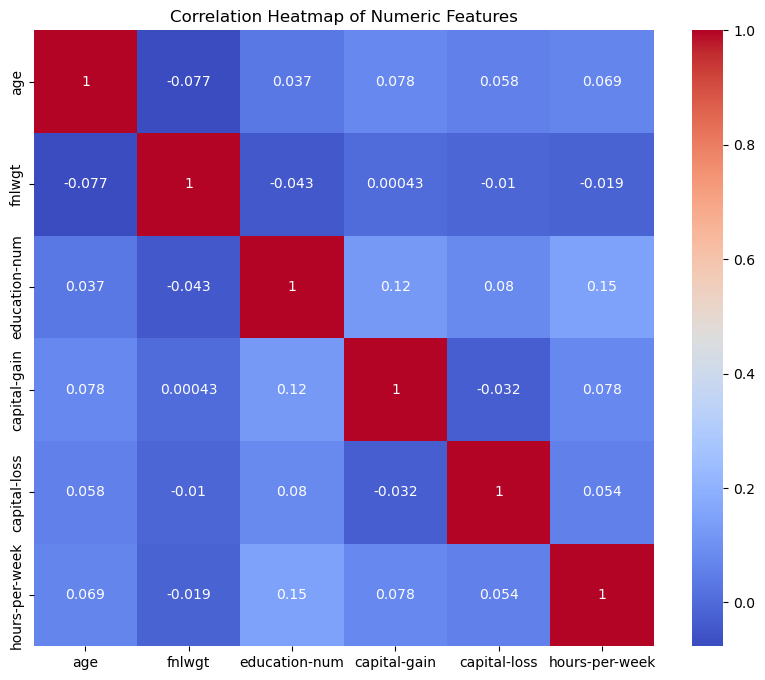

In [49]:

# Plot 1: Income Distribution
sns.countplot(data=df, x='income')
plt.title('Income Distribution')
plt.show()

# Plot 2: Education Levels
plt.figure(figsize=(12, 5))
sns.countplot(data=df, y='education', order=df['education'].value_counts().index)
plt.title('Education Levels')
plt.show()

# Plot 3: Histogram of Age
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.grid(True)
plt.show()

# Plot 4: Boxplot of Hours Worked vs Income
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Hours Worked per Week vs Income')
plt.show()

# Plot 5: Workclass vs Income
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='workclass', hue='income', order=df['workclass'].value_counts().index)
plt.title('Income Distribution Across Workclass Types')
plt.xlabel('Count')
plt.ylabel('Workclass')
plt.tight_layout()
plt.show()

# Plot 6: Age KDE by Income
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='age', hue='income', fill=True)
plt.title('Age Distribution by Income Group')
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Plot 7: Average Hours per Education
edu_hours = df.groupby('education')['hours-per-week'].mean().sort_values()
plt.figure(figsize=(10, 5))
edu_hours.plot(kind='barh', color='pink')
plt.xlabel('Average Hours Per Week')
plt.title('Average Working Hours by Education Level')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Hypothesis 1: Education vs Income

Null Hypothesis (H0): Education level and income are independent.  
Alternative Hypothesis (HA): People with higher education are more likely to earn over 50K.


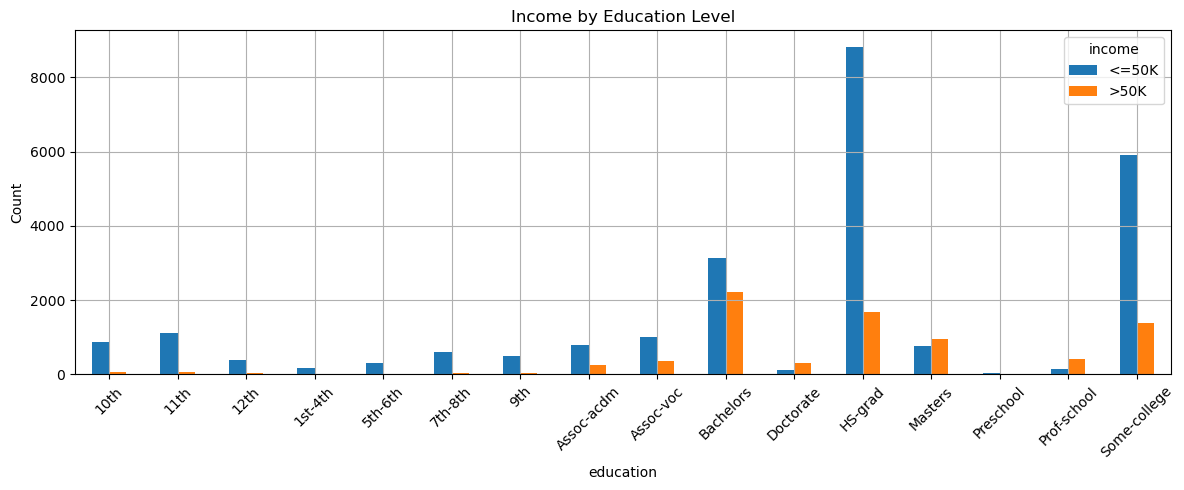

Chi-square Stat: 4429.653302288619
p-value: 0.0


In [29]:
edu_income_ct = pd.crosstab(df['education'], df['income'])

edu_income_ct.plot(kind='bar', figsize=(12, 5))
plt.title('Income by Education Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

chi2_stat1, p_val1, dof1, _ = chi2_contingency(edu_income_ct)
print("Chi-square Stat:", chi2_stat1)
print("p-value:", p_val1)



### Results and Analysis of Hypothesis 1

The bar chart above shows how income is distributed across different education levels. Visually, it seems like people with higher education (like Bachelors and above) are more likely to earn over 50K.

We ran a chi-square test to confirm this and got:

- Chi-square stat: (value above)
- p-value: (value above)

Since the p-value is less than 0.05, we reject the null hypothesis and accept the alternative. There is significant evidence that income is related to education level.


## Hypothesis 2: Gender vs Income

Null Hypothesis (H0): Gender and income are independent.  
Alternative Hypothesis (HA): Men are more likely to earn over 50K than women.


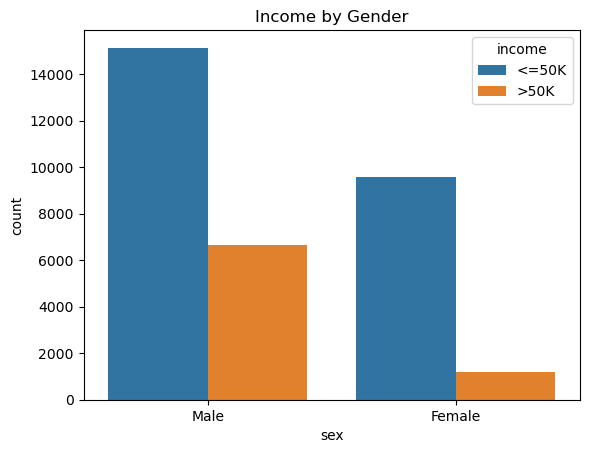

Chi-square Stat: 1517.813409134445
p-value: 0.0


In [33]:
sns.countplot(data=df, x='sex', hue='income')
plt.title('Income by Gender')
plt.show()

gender_income_ct = pd.crosstab(df['sex'], df['income'])

chi2_stat2, p_val2, dof2, _ = chi2_contingency(gender_income_ct)
print("Chi-square Stat:", chi2_stat2)
print("p-value:", p_val2)


### Results and Analysis of Hypothesis 2

This plot shows income distribution by gender. From the countplot, it’s clear that a larger proportion of men earn more than 50K compared to women.

We ran a chi-square test to see if the relationship was significant.

- Chi-square stat: (value above)
- p-value: (value above)

Again, since the p-value is less than 0.05, we reject the null. This suggests that income and gender are related in this dataset, with men more likely to be high earners.


## Hypothesis 3: Hours Worked per Week vs Income

Null Hypothesis (H0): People who earn >50K and <=50K work the same average number of hours.  
Alternative Hypothesis (HA): People who earn >50K work more hours per week on average.


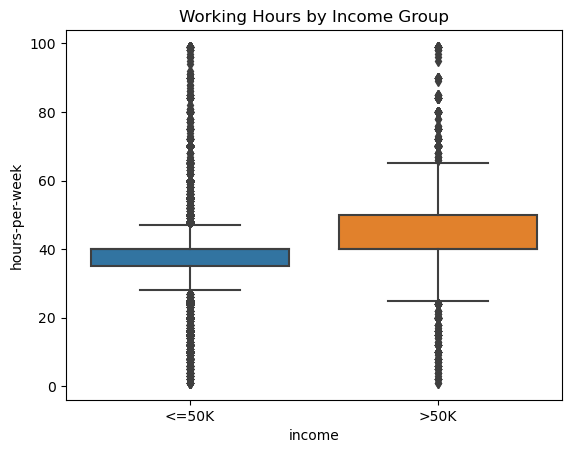

T-test Statistic: 45.123095093109875
p-value: 0.0


In [37]:
low_income = df[df['income'] == '<=50K']['hours-per-week']
high_income = df[df['income'] == '>50K']['hours-per-week']

t_stat, p_val3 = ttest_ind(high_income, low_income, equal_var=False)

sns.boxplot(data=df, x='income', y='hours-per-week')
plt.title('Working Hours by Income Group')
plt.show()

print("T-test Statistic:", t_stat)
print("p-value:", p_val3)



### Results and Analysis of Hypothesis 3

This boxplot shows that people who earn more than 50K tend to work slightly more hours per week on average.

To confirm if the difference is significant, we ran an independent t-test.

- T-test statistic: (value above)
- p-value: (value above)

Since the p-value is below 0.05, we reject the null hypothesis. This means that people who earn over 50K do tend to work more hours per week, on average, than those who earn less.


## Conclusion

All three hypotheses were supported by statistical evidence.  
- Income is related to education level.  
- Men are more likely to earn >50K than women.  
- People who earn more tend to work more hours.

These findings make sense and align with common assumptions about income and socioeconomic factors.


In [51]:
import os
os.getcwd()


'/Users/giagupta'